## Garch model

### Environment setting

In [1]:
from numpy import sqrt, exp, pi, log, inf
import time
import numpy as np
import pandas as pd
import numpy.random as npr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from scipy.optimize import minimize, LinearConstraint
from scipy.integrate import quad
from scipy.interpolate import interp1d
import yfinance as yf

### Recursion formula coefficients

In [ ]:
def recursion(params_mle, steps, phi):
    A, B1 = 0.0+0.0j , 0.0+0.0j
    for _ in range(steps):
        A_next, B1_next = A, B1
        A = A_next + phi*params_mle['r'] + B1_next*params_mle['omega'] - 0.5*np.log(1 - 2*params_mle['alpha']*B1_next)
        B1 = phi*(params_mle['lambda_']+params_mle['gamma']) - 0.5*params_mle['gamma']**2 + params_mle['beta']*B1_next + \
         0.5*(phi-params_mle['gamma'])**2 / (1 - 2*params_mle['alpha']*B1_next)
    return A, B1

### Generating function

In [ ]:
def generating_function(phi, params_mle, S0, h0, steps):
    A, B1 = recursion(params_mle, steps, phi)
    f=(S0**phi) * np.exp(A + B1*h0)
    return f

### Define integrals

In [ ]:
def p1_integrand(phi, params_mle, S0, h0, K, steps):
    f_val = generating_function(phi * 1j + 1, params_mle, S0, h0, steps)
    denominator = phi * 1j * S0 * np.exp(params_mle['r'] * steps)
    return (K**(-phi * 1j) * f_val / denominator).real

def p2_integrand(phi, params_mle, S0, h0, K, steps):
    f_val = generating_function(phi * 1j, params_mle, S0, h0, steps)
    return (K**(-phi * 1j) * f_val / (phi * 1j)).real

### Option price

In [ ]:
def option_price(params_mle, S0, h0, K, steps):
    r = params_mle['r']
    int1, _ = quad(p1_integrand, 1e-4, 1000, args=(params_mle, S0, h0, K, steps))
    P1 = 0.5 + (1 / np.pi) * int1
    int2, _ = quad(p2_integrand, 1e-4, 1000, args=(params_mle, S0, h0, K, steps))
    P2 = 0.5 + (1 / np.pi) * int2
    price = S0 * P1 - K * np.exp(-r * steps) * P2
    return price

### Check the closed form exist

Calculating Closed-form price via Fourier transform...
	 GARCH model call option price  :	3.2450

Simulation results for GARCH model
	Simulation elapsed   5.19 seconds
** The Model : GARCH
	NPaths :     1000	mean : 3.2385	standard deviation : 0.0433	relative difference : 0.2000%
	NPaths :     5000	mean : 3.2400	standard deviation : 0.0193	relative difference : 0.1550%
	NPaths :    10000	mean : 3.2380	standard deviation : 0.0136	relative difference : 0.2149%
	NPaths :    50000	mean : 3.2382	standard deviation : 0.0061	relative difference : 0.2099%
	NPaths :   100000	mean : 3.2383	standard deviation : 0.0043	relative difference : 0.2054%


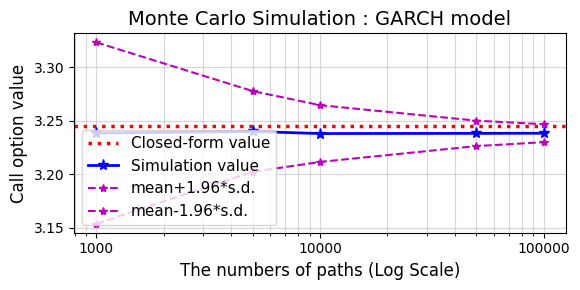

In [ ]:
def simulations(NPaths, steps, S0, h0, r, omega, alpha, beta, gamma, lambda_, K):
    half_N = NPaths // 2
    log_S_pos = np.full(half_N, np.log(S0))
    log_S_neg = np.full(half_N, np.log(S0))
    h_pos = np.full(half_N, h0)
    h_neg = np.full(half_N, h0)
    
    gamma_star = gamma + lambda_ + 0.5

    for t in range(steps):
        z = np.random.normal(0, 1, half_N)
        
        log_S_pos += r - 0.5 * h_pos + np.sqrt(h_pos) * z
        h_pos = omega + beta * h_pos + alpha * (z - gamma_star * np.sqrt(h_pos))**2
        
        log_S_neg += r - 0.5 * h_neg + np.sqrt(h_neg) * (-z)
        h_neg = omega + beta * h_neg + alpha * ((-z) - gamma_star * np.sqrt(h_neg))**2
        
        h_pos = np.maximum(h_pos, 1e-10)
        h_neg = np.maximum(h_neg, 1e-10)

    final_S = np.concatenate([np.exp(log_S_pos), np.exp(log_S_neg)])
    payOff_PV = np.exp(-r * steps) * np.maximum(final_S - K, 0)
    
    return np.mean(payOff_PV), np.std(payOff_PV, ddof=1) / np.sqrt(NPaths)
def simulation_GARCH(NPaths, steps, S0, h0, r, omega, alpha, beta, gamma, lambda_, K, modelPricingValue, ModelName):
    size_paths = len(NPaths)
    size_models = len(ModelName)
    optionValue = np.zeros((size_models, size_paths))
    standardDeviation = np.zeros((size_models, size_paths))
    
    print("\nSimulation results for GARCH model")
    start_time = time.time()
    
    for index_path in range(size_paths):
        val, sd = simulations(NPaths[index_path], steps, S0, h0, r, omega, alpha, beta, gamma, lambda_, K)
        optionValue[0, index_path] = val
        standardDeviation[0, index_path] = sd
        
    ElapsedTime = time.time() - start_time
    print(f"\tSimulation elapsed {ElapsedTime:6.2f} seconds")

    for index_model in range(size_models):
        print(f"** The Model : {ModelName[index_model]}")
        theo_price = modelPricingValue[index_model]
        for index_path in range(size_paths):
            sim_price = optionValue[index_model, index_path]
            sim_sd = standardDeviation[index_model, index_path]
            rel_diff = (theo_price - sim_price) / theo_price * 100 if theo_price != 0 else 0
            print(f"\tNPaths : {NPaths[index_path]:8d}\tmean : {sim_price:6.4f}\tstandard deviation : {sim_sd:6.4f}\trelative difference : {rel_diff:2.4f}%")

    for index_model in range(size_models):
        plt.figure(figsize=(6, 3))
        
        NPaths_arr = np.array(NPaths)
        sim_values = optionValue[index_model, :]
        sd_values = standardDeviation[index_model, :]
        theo_price = modelPricingValue[index_model]
        
        plt.axhline(y=theo_price, color='r', linestyle=':', linewidth=2.5, label='Closed-form value')
        plt.semilogx(NPaths_arr, sim_values, 'b*-', linewidth=2, markersize=8, label='Simulation value')
        plt.semilogx(NPaths_arr, sim_values + 1.96 * sd_values, 'm*--', linewidth=1.5, label='mean+1.96*s.d.')
        plt.semilogx(NPaths_arr, sim_values - 1.96 * sd_values, 'm*--', linewidth=1.5, label='mean-1.96*s.d.')
        
        plt.title(f'Monte Carlo Simulation : {ModelName[index_model]} model', fontsize=14)
        plt.xlabel('The numbers of paths (Log Scale)', fontsize=12)
        plt.ylabel('Call option value', fontsize=12)
        
        from matplotlib.ticker import ScalarFormatter
        plt.gca().xaxis.set_major_formatter(ScalarFormatter())
        plt.ticklabel_format(style='plain', axis='x')
        
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, which="both", ls="-", alpha=0.5) 
        plt.tight_layout()
        plt.show() 

if __name__ == "__main__":
    np.random.seed(1) 

    S0 = 97 
    K = 94
    steps = 63
    r = 0.01 / 252  
    omega = 6.54e-7
    alpha = 0
    beta = 0
    gamma = 2
    lambda_ =0.2
    h0 = (0.2 / np.sqrt(252))**2  

    params_mle = {
        'omega': omega, 'alpha': alpha, 'beta': beta,
        'gamma': gamma, 'lambda_': lambda_,
        'r': r
    }

    print("Calculating Closed-form price via Fourier transform...")
    GARCH_price = option_price(params_mle, S0, h0, K, steps)
    
    print(f"\t {'GARCH model call option price':<30} :\t{GARCH_price:6.4f}")

    NPaths = [1000, 5000, 10000, 50000, 100000]
    ModelName = ['GARCH']

    simulation_GARCH(NPaths, steps, S0, h0, r, omega, alpha, beta, gamma, lambda_, K, [GARCH_price], ModelName)

### Parameters calibration

In [ ]:
def calibration_objective(params_vec, S0, h0, calib_set, r):
    omega, alpha, beta, gamma, lambda_ = params_vec
    
    persistence = beta + alpha * (gamma**2)
    if persistence >= 0.999:
        return 1e10
    
    params_temp = {
        'omega': omega, 'alpha': alpha, 'beta': beta,
        'gamma': gamma, 'lambda_': lambda_,
        'r': r
    }
    total_sq_error = 0
    try:
        for _, row in calib_set.iterrows():
            model_p = option_price(params_temp, S0, h0, row['K'], int(row['DTE']))
            total_sq_error += (model_p - row['P'])**2
        return total_sq_error / len(calib_set)
    except:
        return 1e10

### Compute RMSE

In [ ]:
df_options = pd.read_csv('2020data.csv')
df_rates = pd.read_csv('par-yield-curve-rates-2020-2023.csv')

df_options['date'] = pd.to_datetime(df_options['date'], format='%Y%m%d')
df_rates['date'] = pd.to_datetime(df_rates['date'])

df_rates = df_rates[['date', '1 yr']]
df_rates['r_daily'] = (df_rates['1 yr'] / 100.0) / 252.0

df = pd.merge(df_options, df_rates, on='date', how='inner')

groups = df.groupby('date')

params = np.array([6.54e-7, 1.68e-6, 0.7, 2.0, 0.2])
bounds = [
    (1e-12, 1e-5),
    (1e-12, 0.05),
    (0.5, 0.99),
    (0.0, 10.0),
    (-0.5, 0.5)
]

results = []

for date, data in groups:

    if len(data) > 30:
        mny = (data['S'] / data['K']).values
        idx = np.argsort(mny)
        pick = np.linspace(0, len(idx)-1, 30).astype(int)
        calib = data.iloc[idx[pick]]
    else:
        calib = data
   
    S0 = calib['S'].iloc[0]
    r_today = calib['r_daily'].iloc[0] 
    h0 = (calib['impl_volatility'].mean() / np.sqrt(252))**2
    
    res = minimize(
    calibration_objective,
    params,
    args=(S0, h0, calib, r_today), 
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 20, 'ftol': 1e-3}
)
    params = res.x

    results.append([
        date, *params,
        np.sqrt(res.fun),
        S0,
        calib['impl_volatility'].mean(),
        r_today
    ])

    print(f"{date} | RMSE={np.sqrt(res.fun):.4f}")

cols = ['date','omega','alpha','beta','gamma','lambda','RMSE','S','Avg_IV','r']
pd.DataFrame(results, columns=cols).to_csv('hn_garch_daily_params.csv', index=False)

2020-01-02 00:00:00 | RMSE=5.2029
2020-01-03 00:00:00 | RMSE=4.7534
2020-01-06 00:00:00 | RMSE=4.1540
2020-01-07 00:00:00 | RMSE=5.2915
2020-01-08 00:00:00 | RMSE=5.4079
2020-01-09 00:00:00 | RMSE=5.9873
2020-01-10 00:00:00 | RMSE=4.2838
2020-01-13 00:00:00 | RMSE=5.0034
2020-01-14 00:00:00 | RMSE=4.4643
2020-01-15 00:00:00 | RMSE=4.6593
2020-01-16 00:00:00 | RMSE=4.6601
2020-01-17 00:00:00 | RMSE=3.2429
2020-01-21 00:00:00 | RMSE=4.7589
2020-01-22 00:00:00 | RMSE=5.2814
2020-01-23 00:00:00 | RMSE=4.4851
2020-01-24 00:00:00 | RMSE=5.0671
2020-01-27 00:00:00 | RMSE=5.9817
2020-01-28 00:00:00 | RMSE=4.9813
2020-01-29 00:00:00 | RMSE=4.5556
2020-01-30 00:00:00 | RMSE=4.7001
2020-01-31 00:00:00 | RMSE=6.9876
2020-02-03 00:00:00 | RMSE=5.9023
2020-02-04 00:00:00 | RMSE=4.3034
2020-02-05 00:00:00 | RMSE=3.7250
2020-02-06 00:00:00 | RMSE=4.2193
2020-02-07 00:00:00 | RMSE=3.9691
2020-02-10 00:00:00 | RMSE=4.3229
2020-02-11 00:00:00 | RMSE=3.5824
2020-02-12 00:00:00 | RMSE=3.2127
2020-02-13 00:

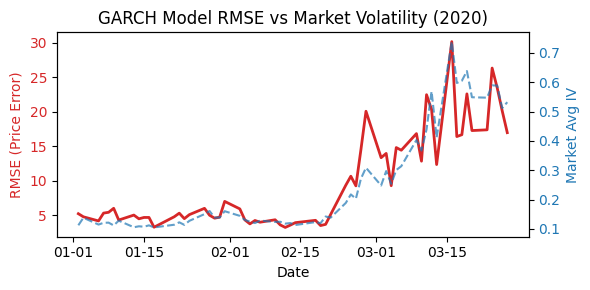

In [ ]:
df_garch = pd.read_csv('hn_garch_daily_params.csv')
df_garch["date"] = pd.to_datetime(df_garch["date"])

fig, ax1 = plt.subplots(figsize=(6, 3))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('RMSE (Price Error)', color=color)
ax1.plot(df_garch['date'], df_garch['RMSE'], color=color, lw=2, label='GARCH RMSE')
ax1.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


plt.setp(ax1.get_xticklabels(), rotation=0, ha='center') 

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Market Avg IV', color=color)
ax2.plot(df_garch['date'], df_garch['Avg_IV'], color=color, linestyle='--', alpha=0.7, label='Market IV')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('GARCH Model RMSE vs Market Volatility (2020)')
fig.tight_layout()
plt.show()

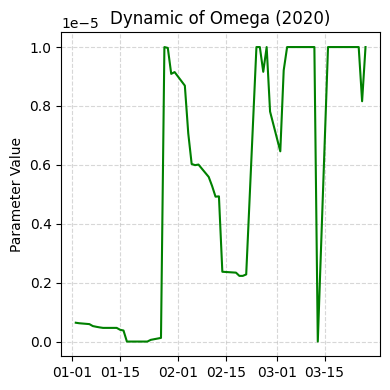

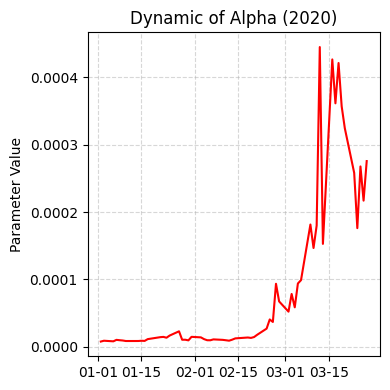

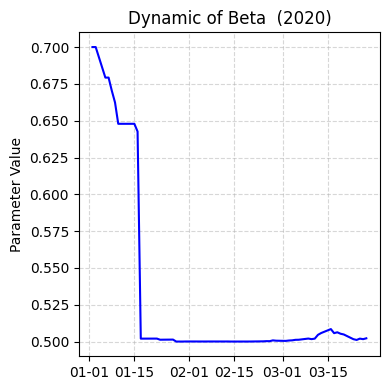

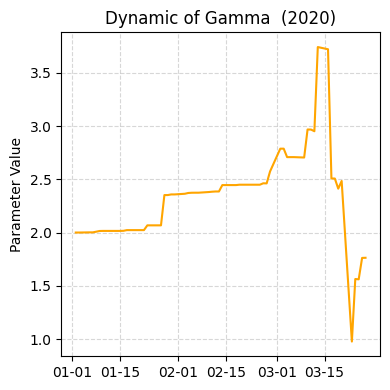

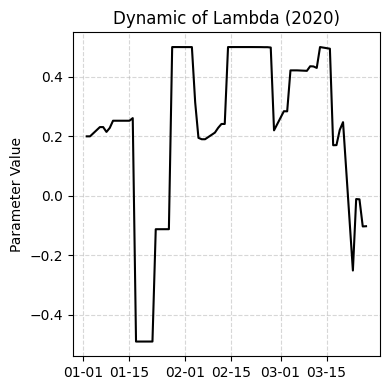

In [ ]:
df_garch = pd.read_csv('hn_garch_daily_params.csv')
df_garch["date"] = pd.to_datetime(df_garch["date"])

params = [
    ('omega', 'green', 'Omega'),
    ('alpha', 'red', 'Alpha'),
    ('beta', 'blue', 'Beta '),
    ('gamma', 'orange', 'Gamma '),
    ('lambda', 'black', 'Lambda')
]

for col, color, title in params:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot(df_garch['date'], df_garch[col], color=color, linewidth=1.5)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.title(f'Dynamic of {title} (2020)')
    ax.set_ylabel('Parameter Value')
    fig.tight_layout()
    plt.show()

## Heston model

### Characteristic function

In [3]:
def heston_cf_core(phi, T, x, v, r, kappa, theta, sigma, rho, lambd):
    i = 1j
    u = -0.5
    b = kappa + lambd
    a = kappa * theta
    d = np.sqrt((rho * sigma * phi * i - b)**2 - (sigma**2) * (2 * u * phi * i - phi**2))
    g = (b - rho * sigma * phi * i + d) / (b - rho * sigma * phi * i - d)
    exp_dt = np.exp(d * T)
    D = ((b - rho * sigma * phi * i + d) / (sigma**2)) * ((1 - exp_dt) / (1 - g * exp_dt))
    C = (r * phi * i * T + (a / (sigma**2)) * ((b - rho * sigma * phi * i + d) * T - 2 * np.log((1 - g * exp_dt) / (1 - g))))
    return np.exp(C + D * v + i * phi * x)

### FFT for option price

In [4]:
def heston_fft_price(S0, K, r, T, params):
    kappa, theta, sigma, rho, v0 = params
    lambd = 0.0
    alpha = 0.75  

    N = 1000      
    upper_bound = 100
    dv = upper_bound / N
    v_j = np.linspace(0.5 * dv, upper_bound - 0.5 * dv, N) 
    
    x = np.log(S0)
    i = 1j

    K = np.atleast_1d(K)
    results = []

    for k in K:
        k_log = np.log(k)
        
        phi_j = v_j - (alpha + 1) * i
        
        cf = heston_cf_core(phi_j, T, x, v0, r, kappa, theta, sigma, rho, lambd)
        
        denominator = (alpha**2 + alpha - v_j**2 + i * (2 * alpha + 1) * v_j)
        psi_v = (np.exp(-r * T) * cf) / denominator
     
        integral_term = np.real(np.exp(-i * v_j * k_log) * psi_v)
        
        integral_value = np.sum(integral_term) * dv
        
        price = (np.exp(-alpha * k_log) / np.pi) * integral_value
        results.append(price)

    return np.array(results) if len(results) > 1 else results[0]

### Check the closed form exist

Calculating Closed-form price via FFT...
	 SV model call option price     :	5.7979

Simulation results
	Simulation elapsed  19.88 seconds
** The Model : SV
	NPaths :     1000	mean : 5.7236	standard deviation : 0.2200	relative differance : 1.2822%
	NPaths :     5000	mean : 5.7160	standard deviation : 0.0990	relative differance : 1.4130%
	NPaths :    10000	mean : 5.7082	standard deviation : 0.0696	relative differance : 1.5473%
	NPaths :    50000	mean : 5.7739	standard deviation : 0.0313	relative differance : 0.4140%
	NPaths :   100000	mean : 5.7932	standard deviation : 0.0222	relative differance : 0.0810%


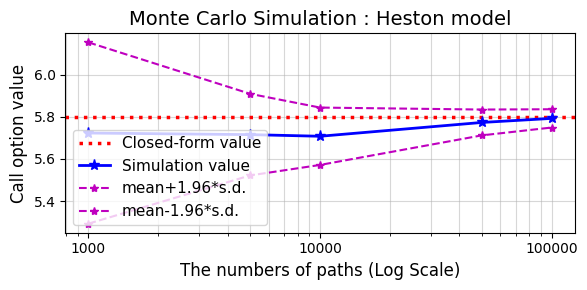

In [ ]:
def simulations(NPaths, NSteps, S0, v0, r, tau, kappa, theta, sigma, rho, K):
    deltaT = tau / NSteps
    vPaths = np.zeros((NPaths, NSteps + 1))
    log_sPaths = np.zeros((NPaths, NSteps + 1))
    
    w0 = np.random.standard_normal((NPaths, NSteps))
    w1 = np.random.standard_normal((NPaths, NSteps))
    w2 = rho * w1 + np.sqrt(1 - rho**2) * w0
    
    vPaths[:, 0] = v0
    log_sPaths[:, 0] = np.log(S0)
    
    for t in range(1, NSteps + 1):
        prev_v = vPaths[:, t-1]
        vPaths[:, t] = prev_v + kappa * (theta - prev_v) * deltaT + \
                       sigma * np.sqrt(np.maximum(prev_v, 0)) * np.sqrt(deltaT) * w2[:, t-1]
        vPaths[:, t] = np.maximum(vPaths[:, t], 0) 
        log_sPaths[:, t] = log_sPaths[:, t-1] + (r - 0.5 * vPaths[:, t-1]) * deltaT + \
                           np.sqrt(np.maximum(vPaths[:, t-1], 0) * deltaT) * w1[:, t-1]
    
    sPaths = np.exp(log_sPaths)
    payOff_PV = np.exp(-r * tau) * np.maximum(sPaths[:, -1] - K, 0)
    
    value = np.mean(payOff_PV)
    standardDeviation = np.std(payOff_PV, ddof=1) / np.sqrt(NPaths)
    
    return value, standardDeviation

def simulation_SV(NPaths, NSteps, S0, v0, r, tau, kappa, theta, sigma, rho, K, modelPricingValue, ModelName):
    size_paths = len(NPaths)
    size_models = len(ModelName)
    optionValue = np.zeros((size_models, size_paths))
    standardDeviation = np.zeros((size_models, size_paths))
    
    print("\nSimulation results")
    start_time = time.time()
    
    for index_path in range(size_paths):
        val, sd = simulations(NPaths[index_path], NSteps, S0, v0, r, tau, kappa, theta, sigma, rho, K)
        optionValue[0, index_path] = val
        standardDeviation[0, index_path] = sd
        
    ElapsedTime = time.time() - start_time
    print(f"\tSimulation elapsed {ElapsedTime:6.2f} seconds")
    
    for index_model in range(size_models):
        print(f"** The Model : {ModelName[index_model]}")
        theo_price = modelPricingValue[index_model]
        for index_path in range(size_paths):
            sim_price = optionValue[index_model, index_path]
            sim_sd = standardDeviation[index_model, index_path]
            rel_diff = (theo_price - sim_price) / theo_price * 100
            print(f"\tNPaths : {NPaths[index_path]:8d}\tmean : {sim_price:6.4f}\tstandard deviation : {sim_sd:6.4f}\trelative differance : {rel_diff:2.4f}%")

    for index_model in range(size_models):
        plt.figure(figsize=(6, 3))
        
        NPaths_arr = np.array(NPaths)
        sim_values = optionValue[index_model, :]
        sd_values = standardDeviation[index_model, :]
        theo_price = modelPricingValue[index_model]
        
        plt.axhline(y=theo_price, color='r', linestyle=':', linewidth=2.5, label='Closed-form value')
        
        plt.semilogx(NPaths_arr, sim_values, 'b*-', linewidth=2, markersize=8, label='Simulation value')
        
        plt.semilogx(NPaths_arr, sim_values + 1.96 * sd_values, 'm*--', linewidth=1.5, label='mean+1.96*s.d.')
        plt.semilogx(NPaths_arr, sim_values - 1.96 * sd_values, 'm*--', linewidth=1.5, label='mean-1.96*s.d.')
        
        plt.title('Monte Carlo Simulation : Heston model', fontsize=14)
        plt.xlabel('The numbers of paths (Log Scale)', fontsize=12)
        plt.ylabel('Call option value', fontsize=12)
        
        from matplotlib.ticker import ScalarFormatter
        plt.gca().xaxis.set_major_formatter(ScalarFormatter())
        plt.ticklabel_format(style='plain', axis='x')
        
        plt.legend(loc='lower left', fontsize=11)
        plt.grid(True, which="both", ls="-", alpha=0.5) 
        plt.tight_layout()
        plt.show() 

if __name__ == "__main__":
    np.random.seed(1) 

    S = 97 
    K = 94
    tau = 0.25
    v = 0.04
    r = 0.02
    kappa = 2  
    theta = 0.04 
    sigma = 0.04 
    rho = -0.7
    
    params = [kappa, theta, sigma, rho, v]

    print("Calculating Closed-form price via FFT...")
    SV_price = heston_fft_price(S, K, r, tau, params)
    
    print(f"\t {'SV model call option price':<30} :\t{SV_price:4.4f}")

    NPaths = [1000, 5000, 10000, 50000, 100000]
    NSteps = 200
    ModelName = ['SV']

    simulation_SV(NPaths, NSteps, S, v, r, tau, kappa, theta, sigma, rho, K, [SV_price], ModelName)

### Parameters calibration

In [ ]:
df_options = pd.read_csv('2020data.csv')
df_rates = pd.read_csv('par-yield-curve-rates-2020-2023.csv')

df_options['date'] = pd.to_datetime(df_options['date'], format='%Y%m%d')
df_rates['date'] = pd.to_datetime(df_rates['date'])

df_rates = df_rates[['date', '1 yr']]
df_rates['r_daily'] = df_rates['1 yr'] / 100.0

df = pd.merge(df_options, df_rates, on='date', how='inner')
groups = df.groupby('date')

# params: [kappa, theta, sigma, rho, v0]
params = np.array([2.0, 0.04, 0.3, -0.7, 0.04]) 
bounds = [
    (0.1, 10.0),   
    (0.001, 1.0),  
    (0.01, 2.0),  
    (-0.95, 0.0),  
    (0.001, 1.0)  
]
results = []
for date, data in groups:
    
    if len(data) > 30:
        mny = (data['S'] / data['K']).values
        idx = np.argsort(mny)
        pick = np.linspace(0, len(idx)-1, 30).astype(int)
        calib = data.iloc[idx[pick]]
    else:
        calib = data

    S0 = calib['S'].iloc[0]
    r_today = calib['r_daily'].iloc[0]
    
    def heston_obj(p):
        kappa, theta, sigma, rho, v0 = p
        if kappa <= 0 or theta <= 0 or sigma <= 0 or not (-1 <= rho <= 1) or v0 <= 0:
            return 1e10
            
        err = 0
        for _, row in calib.iterrows():
            model_p = heston_fft_price(row['S'], row['K'], r_today, row['DTE']/365.0, p)
            err += (model_p - row['P'])**2
            
        return err / len(calib) 

    res = minimize(
        heston_obj,
        params,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 50, 'ftol': 1e-4} 
    )

    if res.success:
        params = res.x

    rmse = np.sqrt(res.fun)
    results.append([date, *params, rmse, S0, r_today ,calib['impl_volatility'].mean()])

    print(f"{date.date()} | RMSE={rmse:.4f} | Kappa={params[0]:.2f} | Rho={params[3]:.2f}")

cols = ['date', 'kappa', 'theta', 'sigma', 'rho', 'v0', 'RMSE', 'S', 'r', 'Avg_IV']
output_df = pd.DataFrame(results, columns=cols)
output_df.to_csv('heston_daily_params.csv', index=False)

2020-01-02 | RMSE=2.1945 | Kappa=1.97 | Rho=-0.70
2020-01-03 | RMSE=1.2300 | Kappa=0.70 | Rho=-0.77
2020-01-06 | RMSE=1.6379 | Kappa=0.88 | Rho=-0.79
2020-01-07 | RMSE=1.7509 | Kappa=0.82 | Rho=-0.80
2020-01-08 | RMSE=2.5076 | Kappa=1.62 | Rho=-0.87
2020-01-09 | RMSE=2.0272 | Kappa=1.63 | Rho=-0.87
2020-01-10 | RMSE=1.4309 | Kappa=1.63 | Rho=-0.87
2020-01-13 | RMSE=1.8624 | Kappa=1.63 | Rho=-0.87
2020-01-14 | RMSE=1.8106 | Kappa=1.64 | Rho=-0.87
2020-01-15 | RMSE=2.0128 | Kappa=1.71 | Rho=-0.90
2020-01-16 | RMSE=2.0302 | Kappa=1.72 | Rho=-0.91
2020-01-17 | RMSE=1.9769 | Kappa=1.79 | Rho=-0.94
2020-01-21 | RMSE=1.7773 | Kappa=2.75 | Rho=-0.70
2020-01-22 | RMSE=2.3394 | Kappa=2.87 | Rho=-0.66
2020-01-23 | RMSE=2.5833 | Kappa=2.88 | Rho=-0.66
2020-01-24 | RMSE=2.7887 | Kappa=2.88 | Rho=-0.66
2020-01-27 | RMSE=2.1146 | Kappa=2.39 | Rho=-0.83
2020-01-28 | RMSE=1.9909 | Kappa=2.42 | Rho=-0.83
2020-01-29 | RMSE=1.7354 | Kappa=2.43 | Rho=-0.83
2020-01-30 | RMSE=1.9040 | Kappa=2.23 | Rho=-0.77


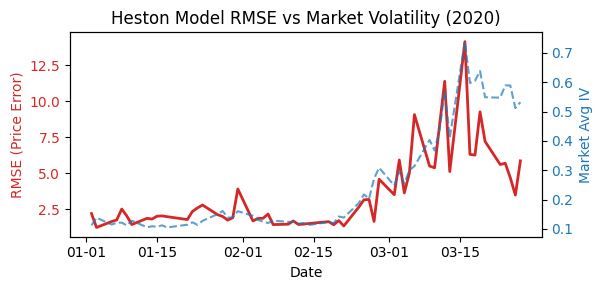

In [ ]:
df_he = pd.read_csv('heston_daily_params.csv')
df_he["date"] = pd.to_datetime(df_he["date"])

fig, ax1 = plt.subplots(figsize=(6, 3))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('RMSE (Price Error)', color=color)
ax1.plot(df_he['date'], df_he['RMSE'], color=color, lw=2, label='Heston RMSE')
ax1.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.setp(ax1.get_xticklabels(), rotation=0, ha='center') 

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Market Avg IV', color=color)
ax2.plot(df_garch['date'], df_garch['Avg_IV'], color=color, linestyle='--', alpha=0.7, label='Market IV')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Heston Model RMSE vs Market Volatility (2020)')
fig.tight_layout()
plt.show()

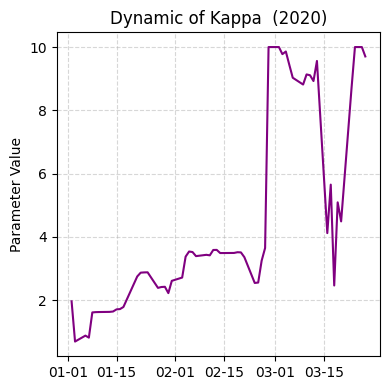

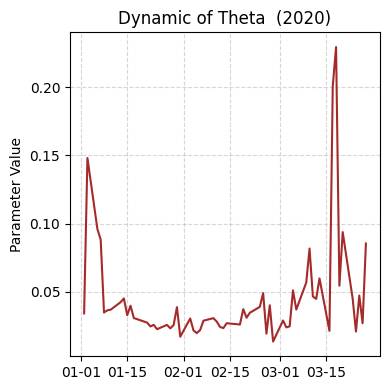

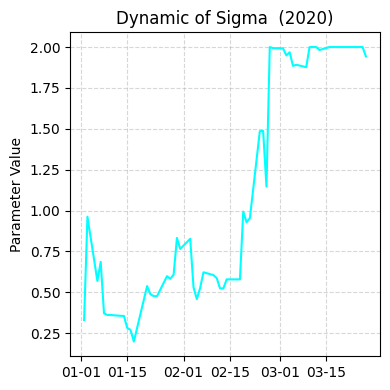

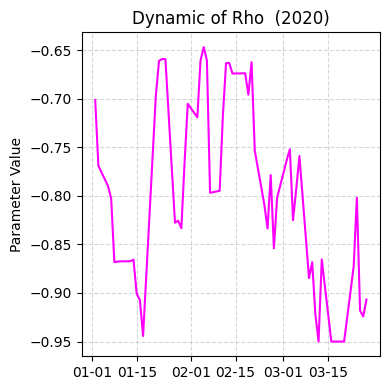

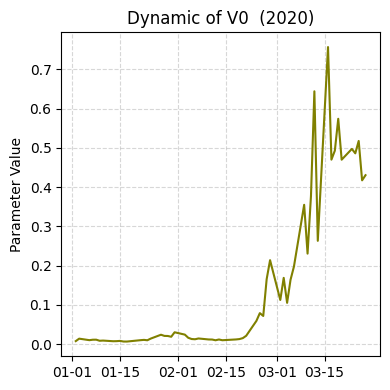

In [ ]:
df_heston = pd.read_csv('heston_daily_params.csv')
df_heston["date"] = pd.to_datetime(df_heston["date"])

heston_params = [
    ('kappa', 'purple', 'Kappa '),
    ('theta', 'brown', 'Theta '),
    ('sigma', 'cyan', 'Sigma '),
    ('rho', 'magenta', 'Rho '),
    ('v0', 'olive', 'V0 ')
]

for col, color, title in heston_params:
    if col in df_heston.columns:
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.plot(df_heston['date'], df_heston[col], color=color, linewidth=1.5)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(f'Dynamic of {title} (2020)')
        ax.set_ylabel('Parameter Value')
        plt.tight_layout()
        plt.show()

### In and Out of sample pricing error

In [ ]:
df_params = pd.read_csv('hn_garch_daily_params.csv')
df_options = pd.read_csv('2020data.csv') 
df_params.columns = df_params.columns.str.strip()
df_options.columns = df_options.columns.str.strip()
df_params['date'] = pd.to_datetime(df_params['date']).dt.normalize()
df_options['date'] = pd.to_datetime(df_options['date'], format='%Y%m%d').dt.normalize()

all_residuals = []

groups = df_options.groupby('date')

for date, data in groups:
    if date not in df_params['date'].values:
        continue
        
    p_row = df_params[df_params['date'] == date].iloc[0]
    
    if len(data) > 30:
        mny = (data['S'] / data['K']).values
        idx = np.argsort(mny)
        pick = np.linspace(0, len(idx)-1, 30).astype(int)
        calib = data.iloc[idx[pick]]
    else:
        calib = data
        
    avg_iv = calib['impl_volatility'].mean()
    h0_today = (avg_iv / np.sqrt(252))**2
    
    raw_r = float(p_row['r'])
    daily_r = raw_r / 252.0 if raw_r > 0.001 else raw_r

    params_dict = {
        'omega': float(p_row['omega']),
        'alpha': float(p_row['alpha']),
        'beta':  float(p_row['beta']),
        'gamma': float(p_row['gamma']),
        'lambda_':float(p_row['lambda']),
        'r':     daily_r  
    }
    
    S0 = float(p_row['S'])

    for _, row in calib.iterrows():
        days = int(row['DTE'])
        model_p = option_price(params_dict, S0, h0_today, float(row['K']), days)
        all_residuals.append({
            'date': date,
            'moneyness': S0 / row['K'],
            'dte': days,
            'error': model_p - row['P']
        })

df_res = pd.DataFrame(all_residuals)
    
df_res['Mny_Group'] = pd.cut(df_res['moneyness'], 
                                 bins=[0, 0.97, 1.03, np.inf], 
                                 labels=['OTM', 'ATM', 'ITM'])
df_res['DTE_Group'] = pd.cut(df_res['dte'], 
                                 bins=[0, 30, 90, np.inf], 
                                 labels=['Short', 'Mid', 'Long'])

final_analysis = df_res.groupby(['Mny_Group', 'DTE_Group'], observed=False)['error'].agg(['mean', 'std'])

print("\n=== HN-GARCH 樣本內定價誤差分析表 ===")
print(final_analysis)
final_analysis.to_csv('garch_results.csv')


=== HN-GARCH 樣本內定價誤差分析表 ===
                          mean        std
Mny_Group DTE_Group                      
OTM       Short      -6.110129   9.125006
          Mid         2.107580   8.195717
          Long       10.673885  16.594532
ATM       Short      -4.730986  12.249956
          Mid        -1.649413   7.177973
          Long       -2.542212   6.851437
ITM       Short      -9.245389  13.722446
          Mid        -4.871411  10.609523
          Long        4.070862  10.827692


In [5]:
df_params = pd.read_csv('heston_daily_params.csv')
df_options = pd.read_csv('2020data.csv') 
df_params['date'] = pd.to_datetime(df_params['date'])
df_options['date'] = pd.to_datetime(df_options['date'], format='%Y%m%d')

all_residuals = []

groups = df_options.groupby('date')

for date, data in groups:
    if date not in df_params['date'].values:
        continue
    p_row = df_params[df_params['date'] == date].iloc[0]
    p_vec = [p_row['kappa'], p_row['theta'], p_row['sigma'], p_row['rho'], p_row['v0']]
    S0 = p_row['S']
    r_today = p_row['r']

    if len(data) >30:
        mny = (data['S'] / data['K']).values
        idx = np.argsort(mny)
        pick = np.linspace(0, len(idx)-1, 30).astype(int)
        calib = data.iloc[idx[pick]]
    else:
        calib = data
        
    for _, row in calib.iterrows():
        model_p = heston_fft_price(S0, row['K'], r_today, row['DTE']/365.0, p_vec)
        
        all_residuals.append({
            'date': date,
            'moneyness': S0 / row['K'],
            'dte': row['DTE'],
            'error': model_p - row['P'], 
        })
df_res = pd.DataFrame(all_residuals)
df_res['Mny_Group'] = pd.cut(df_res['moneyness'], bins=[0, 0.97, 1.03, np.inf], labels=['OTM', 'ATM', 'ITM'])
df_res['DTE_Group'] = pd.cut(df_res['dte'], bins=[0, 30, 90, np.inf], labels=['Short', 'Mid', 'Long'])

final_analysis = df_res.groupby(['Mny_Group', 'DTE_Group'], observed=False)['error'].agg(['mean', 'std'])
print("=== heston 樣本內定價誤差分析表 ===")
print(final_analysis)
final_analysis.to_csv('heston_results.csv')

=== heston 樣本內定價誤差分析表 ===
                         mean       std
Mny_Group DTE_Group                    
OTM       Short      1.721194  5.113608
          Mid        0.660075  3.019981
          Long      -0.452559  4.120015
ATM       Short     -0.544018  4.466486
          Mid       -0.491122  2.067676
          Long      -0.824584  4.031368
ITM       Short     -3.310500  6.588923
          Mid       -0.046900  4.244386
          Long       3.621192  5.950214


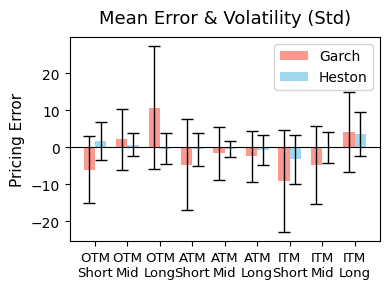

In [ ]:
df_garch = pd.read_csv('garch_results.csv')
df_heston = pd.read_csv('heston_results.csv')

df_garch['Group'] = df_garch['Mny_Group'].astype(str) + '\n' + df_garch['DTE_Group'].astype(str)
df_heston['Group'] = df_heston['Mny_Group'].astype(str) + '\n' + df_heston['DTE_Group'].astype(str)

df = pd.merge(
    df_garch[['Group', 'mean', 'std']], 
    df_heston[['Group', 'mean', 'std']], 
    on='Group', 
    suffixes=('_GARCH', '_Heston')
)

x = np.arange(len(df['Group']))
width = 0.35

fig, ax = plt.subplots(figsize=(4, 3)) 

rects1 = ax.bar(x - width/2, df['mean_GARCH'], width, yerr=df['std_GARCH'], 
                label='Garch', capsize=4, color='salmon', alpha=0.8, error_kw={'elinewidth':1})

rects2 = ax.bar(x + width/2, df['mean_Heston'], width, yerr=df['std_Heston'], 
                label='Heston', capsize=4, color='skyblue', alpha=0.8, error_kw={'elinewidth':1})
ax.set_ylabel('Pricing Error', fontsize=11)
ax.set_title('Mean Error & Volatility (Std)', fontsize=13, pad=10)

ax.set_xticks(x)
ax.set_xticklabels(df['Group'], rotation=0, ha='center', fontsize=9.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

Progress: 55/60 (91.7%)
Done.
Avg IS RMSE: 9.5876
Avg OOS RMSE: 32.6400


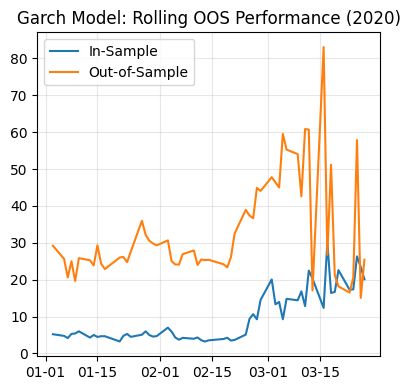

In [ ]:
params_df = pd.read_csv("hn_garch_daily_params.csv").rename(columns=str.strip)
all_data = pd.read_csv("2020data.csv").rename(columns=str.strip)

def parse_date(df):
    s = df["date"].astype(str).str.split(".").str[0]
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce").fillna(
        pd.to_datetime(s, errors="coerce")
    ).dt.normalize()

params_df["date_dt"] = parse_date(params_df)
all_data["date_dt"] = parse_date(all_data)

all_data["DTE"] = all_data["DTE"].astype(int)

dates = sorted(params_df["date_dt"].unique())

def option_price(p, S0, h0, K, T):
    try:
        r = p["r"]

        i1, _ = quad(p1_integrand, 1e-4, 100, args=(p, S0, h0, K, T), limit=50)
        i2, _ = quad(p2_integrand, 1e-4, 100, args=(p, S0, h0, K, T), limit=50)

        P1 = 0.5 + i1 / np.pi
        P2 = 0.5 + i2 / np.pi

        return max(0, S0 * P1 - K * np.exp(-r * (T / 252)) * P2)
    except:
        return np.nan

results = []

n = len(dates)

for i in range(1, n):

    if i % 5 == 0:
        print(f"\rProgress: {i}/{n} ({i/n:.1%})", end="")

    y, t = dates[i - 1], dates[i]

    row = params_df[params_df["date_dt"] == y].iloc[0]

    params = {
        "omega": row["omega"],
        "alpha": row["alpha"],
        "beta": row["beta"],
        "gamma": row["gamma"],
        "lambda_": row["lambda"],
        "r": row["r"],
    }

    h0 = (row["Avg_IV"] / np.sqrt(252)) ** 2

    day = all_data[all_data["date_dt"] == t]
    if day.empty:
        continue
    day = day.iloc[::20]

    S = day["S"].iloc[0]

    Ks = day["K"].values
    DTEs = day["DTE"].values
    Ps = day["P"].values

    preds = [
        option_price(params, S, h0, K, dte)
        for K, dte in zip(Ks, DTEs)
    ]

    preds = np.array(preds)

    mask = ~np.isnan(preds)

    if mask.sum() > 0:
        rmse = np.sqrt(np.mean((Ps[mask] - preds[mask]) ** 2))

        results.append({
            "date": t,
            "IS_RMSE": row["RMSE"],
            "OOS_RMSE": rmse
        })

print("\nDone.")

df = pd.DataFrame(results)

print(f"Avg IS RMSE: {df['IS_RMSE'].mean():.4f}")
print(f"Avg OOS RMSE: {df['OOS_RMSE'].mean():.4f}")

plt.figure(figsize=(4, 4))
plt.plot(df["date"], df["IS_RMSE"], label="In-Sample")
plt.plot(df["date"], df["OOS_RMSE"], label="Out-of-Sample")
plt.title("Garch Model: Rolling OOS Performance (2020)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=0, ha='center')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

In [ ]:
# Heston
try:
    heston_df = pd.read_csv('heston_daily_params.csv')
    heston_params = ['kappa', 'theta', 'sigma', 'rho', 'v0']
    heston_means = heston_df[heston_params].mean()
    
    print("Heston模型參數平均值:")
    for param, val in heston_means.items():
        print(f"{param:<8} : {val:.6f}")
except Exception as e:
    print(f"讀取 Heston 檔案失敗: {e}")

print("\n" + "="*40 + "\n")

# GARCH
try:
    hn_garch_df = pd.read_csv('hn_garch_daily_params.csv')
    hn_garch_params = ['omega', 'alpha', 'beta', 'gamma', 'lambda']
    hn_garch_means = hn_garch_df[hn_garch_params].mean()
    
    print("GARCH模型參數平均值")
    for param, val in hn_garch_means.items():
        print(f"{param:<8} : {val:.8f}")
except Exception as e:
    print(f"讀取 HN-GARCH 檔案失敗: {e}")

=== Heston 模型 5 大參數平均值 ===
kappa    : 4.583878
theta    : 0.045379
sigma    : 1.121638
rho      : -0.803435
v0       : 0.146251


=== HN-GARCH 模型 5 大參數平均值 ===
omega    : 0.00000568
alpha    : 0.00008723
beta     : 0.53162926
gamma    : 2.33507064
lambda   : 0.24473856


開始 Heston 樣本外驗證，總計 59 天...
進度: 10/59
進度: 20/59
進度: 30/59
進度: 40/59
進度: 50/59

Avg IS RMSE: 3.5072
Avg OOS RMSE: 16.6363


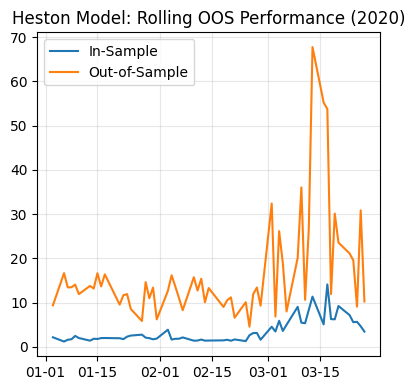

In [ ]:
def heston_cf_core(u, T, x, v0, r, kappa, theta, sigma, rho, lambd=0.0):
    i = 1j
    xi = kappa - lambd - rho * sigma * i * u
    d = np.sqrt(xi**2 + sigma**2 * (u**2 + i * u))
    g = (xi - d) / (xi + d)
    
    C = (r * i * u * T + (kappa * theta / sigma**2) * ((xi - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))))
    D = ((xi - d) / sigma**2) * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    
    return np.exp(C + D * v0 + i * u * x)

def heston_fft_price(S0, K, r, T_days, params):
    try:
        kappa, theta, sigma, rho, v0 = params
        lambd = 0.0
        alpha = 0.75  
        T = T_days / 252 
        N = 1000      
        upper_bound = 100
        dv = upper_bound / N
        v_j = np.linspace(0.5 * dv, upper_bound - 0.5 * dv, N)
        
        x = np.log(S0)
        i = 1j
        k_log = np.log(K)
        
        phi_j = v_j - (alpha + 1) * i
        cf = heston_cf_core(phi_j, T, x, v0, r, kappa, theta, sigma, rho, lambd)
        
        denominator = (alpha**2 + alpha - v_j**2 + i * (2 * alpha + 1) * v_j)
        psi_v = (np.exp(-r * T) * cf) / denominator
     
        integral_term = np.real(np.exp(-i * v_j * k_log) * psi_v)
        integral_value = np.sum(integral_term) * dv
        
        price = (np.exp(-alpha * k_log) / np.pi) * integral_value
        return max(0, float(price))
    except:
        return np.nan

def parse_date(df):
    s = df["date"].astype(str).str.split(".").str[0]
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce").fillna(
        pd.to_datetime(s, errors="coerce")
    ).dt.normalize()
    
params_df = pd.read_csv("heston_daily_params.csv").rename(columns=str.strip)
all_data = pd.read_csv("2020data.csv").rename(columns=str.strip)

params_df["date_dt"] = parse_date(params_df)
all_data["date_dt"] = parse_date(all_data)
all_data["DTE"] = all_data["DTE"].astype(int)

dates = sorted(params_df["date_dt"].unique())

results = []

for i in range(1, len(dates)):
    y_date, t_date = dates[i - 1], dates[i]
    
    row = params_df[params_df["date_dt"] == y_date].iloc[0]
    h_params = [row["kappa"], row["theta"], row["sigma"], row["rho"], row["v0"]]
    r_val = row["r"]
    
    day = all_data[all_data["date_dt"] == t_date].iloc[::20]
    if day.empty: continue
    
    S_today = day["S"].iloc[0]
    
    preds = []
    for _, item in day.iterrows():
        p = heston_fft_price(S_today, item["K"], r_val, item["DTE"], h_params)
        preds.append(p)
    
    preds = np.array(preds)
    market_ps = day["P"].values
    
    mask = ~np.isnan(preds)
    if mask.sum() > 0:
        rmse_oos = np.sqrt(np.mean((market_ps[mask] - preds[mask]) ** 2))
        results.append({
            "date": t_date,
            "IS_RMSE": row["RMSE"],
            "OOS_RMSE": rmse_oos
        })

df_res = pd.DataFrame(results)
print(f"\nAvg IS RMSE: {df_res['IS_RMSE'].mean():.4f}")
print(f"Avg OOS RMSE: {df_res['OOS_RMSE'].mean():.4f}")

plt.figure(figsize=(4, 4))
plt.plot(df_res["date"], df_res["IS_RMSE"], label="In-Sample")
plt.plot(df_res["date"], df_res["OOS_RMSE"], label="Out-of-Sample")
plt.title("Heston Model: Rolling OOS Performance (2020)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()